# Class 9: Big Data for Networks and Beyond

Goals of today's class:
1. Introduction to big data challenges
2. Big O Asymptotic Analysis
3. Probabilistic / estimation algorithms for very big data
4. Introduction to cluster computing
5. Common design patterns for batch jobs
6. Embarassingly parallel versus fully parallel jobs
__________

1. Come in. Sit down. Open Teams.
2. Make sure your notebook from last class is saved.
________

In [1]:
%load_ext jupyter_tikz

In [2]:
import networkx as nx
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import hashlib
from tqdm.notebook import tqdm
# pip install tqdm ipywidgets for the above progress bar

#plt.rcParams['figure.dpi'] = 300
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['text.usetex'] = True

### What is Big Data?

Generally, data that requires special algorithms and preparation to work with because it exceeds the memory, storage, or computational resources available on an ordinary computer.

We can approach big data problems in a number of ways:

1. By subsampling to make the problem smaller
2. By approximating to make the problem simpler
3. By getting a bigger computer

We've talked about network sampling and machine learning extensively, so today we'll be focusing on big data approximation algorithms, and using cluster computers when more hardware is absolutely necessary.

### First: How well does an algorithm scale?

In computer science we often discuss algorithm performance using _Big O notation._ Because we'll be examining what algorithms infeasible with big data, and how to work around these limits, we'll start with a brief tutorial on algorithmic runtime analysis.

In computer science we rarely judge an algorithm by how long it takes to run in seconds, clock cycles, or assembly instructions. Instead, we typically care about how an algorithm _scales_ proportionally to the size of its input.

#### Linear Growth

For a trivial example: given a list of numbers, return their sum:

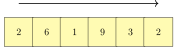

In [6]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=1cm, minimum height=1cm, text centered, text width=0.5cm, draw=black, fill=yellow!30]
\begin{tikzpicture}[]

	\node (i0) [box] {2};
	\node (i1) [box, right of=i0] {6};
	\node (i2) [box, right of=i1] {1};
	\node (i3) [box, right of=i2] {9};
	\node (i4) [box, right of=i3] {3};
	\node (i5) [box, right of=i4] {2};

	\draw [->,thick] ([yshift=0.5cm]i0.north) -- ([yshift=0.5cm]i5.north); 
\end{tikzpicture}

This scales linearly with the length of the list, which we refer to as $O(n)$ where the list length is $n$.

#### Logarithmic Growth

Now consider searching through a stack of exams for a particular student. If the exams are in arbitrary order, we must start at the beginning of the stack and go one by one until we find the student of interest -- $O(n)$ again. Even if the student happens to be near the start of the stack sometimes, the amount we need to search grows linearly on average.

However, what if the exams are stacked in alphabetical order? Now we can perform a binary search, starting at the middle of the stack to learn whether the student is in the first or second half of the exams, then jumping to the middle of the remaining stack, and repeating until we find our student. A search for Rohan might look like:

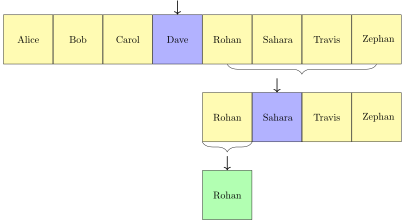

In [8]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=1cm, minimum height=1cm, text centered, text width=1cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (i0) [box] {Alice};
	\node (i1) [box, right = 0 of i0] {Bob};
	\node (i2) [box, right = 0 of i1] {Carol};
	\node (i3) [box, right = 0 of i2, fill=blue!30] {Dave};
	\node (i4) [box, right = 0 of i3] {Rohan};
	\node (i5) [box, right = 0 of i4] {Sahara};
	\node (i6) [box, right = 0 of i5] {Travis};
	\node (i7) [box, right = 0 of i6] {Zephan};

	\draw[<-,thick] (i3.north) -- +(0,0.5);
	\draw [decorate,decoration={brace,amplitude=10pt}, yshift = -0.2cm] (i7.south) -- (i4.south) node (curly)[black,midway,xshift = 0.0 cm] {};

	\node (j4) [box, below = 1 of i4] {Rohan};
	\node (j5) [box, right = 0 of j4, fill=blue!30] {Sahara};
	\node (j6) [box, right = 0 of j5] {Travis};
	\node (j7) [box, right = 0 of j6] {Zephan};

	\draw[<-,thick] (j5.north) -- +(0,0.5);
	\draw [decorate,decoration={brace,amplitude=10pt}, yshift = -0.2cm] (j4.south east) -- (j4.south west) node (curly)[black,midway,xshift = 0.0 cm] {};

	\node (k4) [box, below = 1 of j4, fill=green!30] {Rohan};

	\draw[<-,thick] (k4.north) -- +(0,0.5);

\end{tikzpicture}

Our search still takes longer as the list increases in length, but much less than linearly. When the length of the list doubles we need to perform one additional search. Therefore, this is logarithmic growth, which we write as $O(log\ n)$.

#### Sorting

Sorting will be our first example where different approaches to the problem can have widely divergent performance. Consider two algorithms for sorting a list of numbers: insertion sort, and merge sort.

##### Insertion Sort

One solution to this problem is to move one element at a time, right to left, and for each element, move it to the left until it is in the correct sorted position for the list we have considered so far. This is easiest to explain visually:

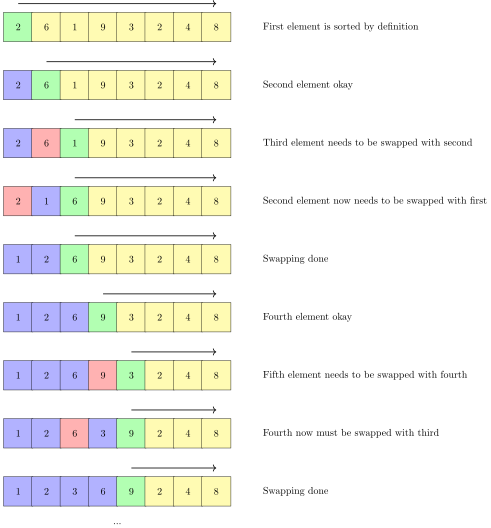

In [9]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=1cm, minimum height=1cm, text centered, text width=0.5cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (i0) [box,fill=green!30] {2};
	\node (i1) [box, right of=i0] {6};
	\node (i2) [box, right of=i1] {1};
	\node (i3) [box, right of=i2] {9};
	\node (i4) [box, right of=i3] {3};
	\node (i5) [box, right of=i4] {2};
	\node (i6) [box, right of=i5] {4};
	\node (i7) [box, right of=i6] {8};
	\draw [->,thick] ([yshift=0.3cm]i0.north) -- ([yshift=0.3cm]i7.north);
	\node (text1) [right= 1 of i7] {First element is sorted by definition};

	\node (j0) [box,fill=blue!30, below=1 of i0] {2};
	\node (j1) [box,fill=green!30, right of=j0] {6};
	\node (j2) [box, right of=j1] {1};
	\node (j3) [box, right of=j2] {9};
	\node (j4) [box, right of=j3] {3};
	\node (j5) [box, right of=j4] {2};
	\node (j6) [box, right of=j5] {4};
	\node (j7) [box, right of=j6] {8};
	\draw [->,thick] ([yshift=0.3cm]j1.north) -- ([yshift=0.3cm]j7.north);
	\node (text2) [right= 1 of j7] {Second element okay};

	\node (k0) [box,fill=blue!30, below=1 of j0] {2};
	\node (k1) [box,fill=red!30, right of=k0] {6};
	\node (k2) [box,fill=green!30, right of=k1] {1};
	\node (k3) [box, right of=k2] {9};
	\node (k4) [box, right of=k3] {3};
	\node (k5) [box, right of=k4] {2};
	\node (k6) [box, right of=k5] {4};
	\node (k7) [box, right of=k6] {8};
	\draw [->,thick] ([yshift=0.3cm]k2.north) -- ([yshift=0.3cm]k7.north);
	\node (text3) [right= 1 of k7] {Third element needs to be swapped with second};

	\node (l0) [box,fill=red!30, below=1 of k0] {2};
	\node (l1) [box,fill=blue!30, right of=l0] {1};
	\node (l2) [box,fill=green!30, right of=l1] {6};
	\node (l3) [box, right of=l2] {9};
	\node (l4) [box, right of=l3] {3};
	\node (l5) [box, right of=l4] {2};
	\node (l6) [box, right of=l5] {4};
	\node (l7) [box, right of=l6] {8};
	\draw [->,thick] ([yshift=0.3cm]l2.north) -- ([yshift=0.3cm]l7.north);
	\node (text4) [right= 1 of l7] {Second element now needs to be swapped with first};

	\node (m0) [box,fill=blue!30, below=1 of l0] {1};
	\node (m1) [box,fill=blue!30, right of=m0] {2};
	\node (m2) [box,fill=green!30, right of=m1] {6};
	\node (m3) [box, right of=m2] {9};
	\node (m4) [box, right of=m3] {3};
	\node (m5) [box, right of=m4] {2};
	\node (m6) [box, right of=m5] {4};
	\node (m7) [box, right of=m6] {8};
	\draw [->,thick] ([yshift=0.3cm]m2.north) -- ([yshift=0.3cm]m7.north);
	\node (text5) [right= 1 of m7] {Swapping done};

	\node (n0) [box,fill=blue!30, below=1 of m0] {1};
	\node (n1) [box,fill=blue!30, right of=n0] {2};
	\node (n2) [box,fill=blue!30, right of=n1] {6};
	\node (n3) [box,fill=green!30, right of=n2] {9};
	\node (n4) [box, right of=n3] {3};
	\node (n5) [box, right of=n4] {2};
	\node (n6) [box, right of=n5] {4};
	\node (n7) [box, right of=n6] {8};
	\draw [->,thick] ([yshift=0.3cm]n3.north) -- ([yshift=0.3cm]n7.north);
	\node (text6) [right= 1 of n7] {Fourth element okay};

	\node (o0) [box,fill=blue!30, below=1 of n0] {1};
	\node (o1) [box,fill=blue!30, right of=o0] {2};
	\node (o2) [box,fill=blue!30, right of=o1] {6};
	\node (o3) [box,fill=red!30, right of=o2] {9};
	\node (o4) [box,fill=green!30, right of=o3] {3};
	\node (o5) [box, right of=o4] {2};
	\node (o6) [box, right of=o5] {4};
	\node (o7) [box, right of=o6] {8};
	\draw [->,thick] ([yshift=0.3cm]o4.north) -- ([yshift=0.3cm]o7.north);
	\node (text7) [right= 1 of o7] {Fifth element needs to be swapped with fourth};

	\node (p0) [box,fill=blue!30, below=1 of o0] {1};
	\node (p1) [box,fill=blue!30, right of=p0] {2};
	\node (p2) [box,fill=red!30, right of=p1] {6};
	\node (p3) [box,fill=blue!30, right of=p2] {3};
	\node (p4) [box,fill=green!30, right of=p3] {9};
	\node (p5) [box, right of=p4] {2};
	\node (p6) [box, right of=p5] {4};
	\node (p7) [box, right of=p6] {8};
	\draw [->,thick] ([yshift=0.3cm]p4.north) -- ([yshift=0.3cm]p7.north);
	\node (text8) [right= 1 of p7] {Fourth now must be swapped with third};

	\node (q0) [box,fill=blue!30, below=1 of p0] {1};
	\node (q1) [box,fill=blue!30, right of=q0] {2};
	\node (q2) [box,fill=blue!30, right of=q1] {3};
	\node (q3) [box,fill=blue!30, right of=q2] {6};
	\node (q4) [box,fill=green!30, right of=q3] {9};
	\node (q5) [box, right of=q4] {2};
	\node (q6) [box, right of=q5] {4};
	\node (q7) [box, right of=q6] {8};
	\draw [->,thick] ([yshift=0.3cm]q4.north) -- ([yshift=0.3cm]q7.north);
	\node (text9) [right= 1 of q7] {Swapping done};


	\node (text) [below=1 of $(q3)!0.5!(q4)$] {...};


\end{tikzpicture}

For the class: What's the runtime of this algorithm?

##### Spoiler



We move across the list left-to-right, which scales $O(n)$. However, for each step of that iteration, we must move elements left until they find their correct position, which _also_ scales linearly for $O(n)$. If we perform an $O(n)$ operation for each step in our $O(n)$ operation, then insertion sort has a runtime of $O(n^2)$ -- exponential growth!

##### Merge Sort

However, we can approach sorting a list in a very different way, by dividing and conquering. I split the list in half and ask Alice to sort the first half, and Bob to sort the second half, and then I merge the two sorted halves. Alice and Bob each divide _their_ lists in half, and find two more people to sort their lists before merging. The process proceeds recursively until a list is only one element long as is therefore sorted by definition.

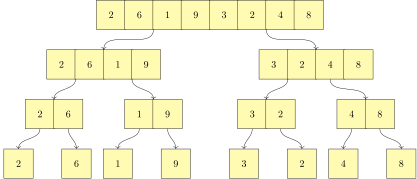

In [3]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=1cm, minimum height=1cm, text centered, text width=0.5cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (i0) [box] {2};
	\node (i1) [box, right of=i0] {6};
	\node (i2) [box, right of=i1] {1};
	\node (i3) [box, right of=i2] {9};
	\node (i4) [box, right of=i3] {3};
	\node (i5) [box, right of=i4] {2};
	\node (i6) [box, right of=i5] {4};
	\node (i7) [box, right of=i6] {8};

	% Layer 1
	\node (j0) [box, below left=1 of i0] {2};
	\node (j1) [box, right of=j0] {6};
	\node (j2) [box, right of=j1] {1};
	\node (j3) [box, right of=j2] {9};

	\node (j4) [box, below right=1 of i4] {3};
	\node (j5) [box, right of=j4] {2};
	\node (j6) [box, right of=j5] {4};
	\node (j7) [box, right of=j6] {8};

	\draw[->] ($(i1.south)!0.5!(i2.south)$) [out=270,in=90] to ($(j1.north)!0.5!(j2.north)$);
	\draw[->] ($(i5.south)!0.5!(i6.south)$) [out=270,in=90] to ($(j5.north)!0.5!(j6.north)$);

	% Layer 2
	\node (k0) [box, below left=1 of j1] {2};
	\node (k1) [box, right of=k0] {6};

	\node (k2) [box, below right=1 of j1] {1};
	\node (k3) [box, right of=k2] {9};

	\node (k4) [box, below left=1 of j5] {3};
	\node (k5) [box, right of=k4] {2};

	\node (k6) [box, below right=1 of j5] {4};
	\node (k7) [box, right of=k6] {8};

	\draw[->] ($(j0.south)!0.5!(j1.south)$) [out=270,in=90] to ($(k0.north)!0.5!(k1.north)$);
	\draw[->] ($(j2.south)!0.5!(j3.south)$) [out=270,in=90] to ($(k2.north)!0.5!(k3.north)$);
	\draw[->] ($(j4.south)!0.5!(j5.south)$) [out=270,in=90] to ($(k4.north)!0.5!(k5.north)$);
	\draw[->] ($(j6.south)!0.5!(j6.south)$) [out=270,in=90] to ($(k6.north)!0.5!(k7.north)$);

	% Layer 3
	\node (l0) [box, below left=1 of k1] {2};
	\node (l1) [box, right=1 of l0] {6};
	\node (l2) [box, below left=1 of k3] {1};
	\node (l3) [box, right=1 of l2] {9};

	\node (l7) [box, below right=1 of k6] {8};
	\node (l6) [box, left=1 of l7] {4};
	\node (l5) [box, below right=1 of k4] {2};
	\node (l4) [box, left=1 of l5] {3};

	\draw[->] (k0) [out=270,in=90] to (l0);
	\draw[->] (k1) [out=270,in=90] to (l1);
	\draw[->] (k2) [out=270,in=90] to (l2);
	\draw[->] (k3) [out=270,in=90] to (l3);
	\draw[->] (k4) [out=270,in=90] to (l4);
	\draw[->] (k5) [out=270,in=90] to (l5);
	\draw[->] (k6) [out=270,in=90] to (l6);
	\draw[->] (k7) [out=270,in=90] to (l7);

\end{tikzpicture}

To merge two sorted lists, one simply needs to look at the top element of each list, decide which goes first, and assemble a third, sorted list:

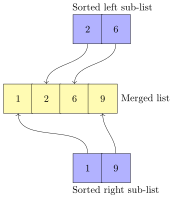

In [4]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=1cm, minimum height=1cm, text centered, text width=0.5cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (i0) [box] {1};
	\node (i1) [box, right of=i0] {2};
	\node (i2) [box, right of=i1] {6};
	\node (i3) [box, right of=i2] {9};
	\node (t0) [anchor=west, right=0 of i3] {Merged list};

	\node (j0) [box, fill=blue!30, above right=2 of i0] {2};
	\node (j1) [box, fill=blue!30, right of=j0] {6};
	\draw[->] (j0.south) [out=270,in=90] to (i1.north);
	\draw[->] (j1.south) [out=270,in=90] to (i2.north);
	\node (t1) [anchor=west, above left=0.2 of j0.north west, label={right,align=left:{Sorted left sub-list}}] {};

	\node (k0) [box, fill=blue!30, below right=2 of i0] {1};
	\node (k1) [box, fill=blue!30, right of=k0] {9};
	\draw[->] (k0.north) [out=90,in=270] to (i0.south);
	\draw[->] (k1.north) [out=90,in=270] to (i3.south);
	\node (t2) [anchor=west, below left=0.2 of k0.south west, label={right,align=left:{Sorted right sub-list}}] {};
 
\end{tikzpicture}

If each worker merges the results of their sub-contractors and then hands the result upwards, our algorithm looks like:

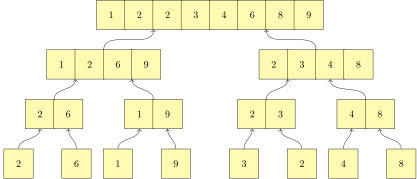

In [5]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=1cm, minimum height=1cm, text centered, text width=0.5cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (i0) [box] {1};
	\node (i1) [box, right of=i0] {2};
	\node (i2) [box, right of=i1] {2};
	\node (i3) [box, right of=i2] {3};
	\node (i4) [box, right of=i3] {4};
	\node (i5) [box, right of=i4] {6};
	\node (i6) [box, right of=i5] {8};
	\node (i7) [box, right of=i6] {9};

	% Layer 1
	\node (j0) [box, below left=1 of i0] {1};
	\node (j1) [box, right of=j0] {2};
	\node (j2) [box, right of=j1] {6};
	\node (j3) [box, right of=j2] {9};

	\node (j4) [box, below right=1 of i4] {2};
	\node (j5) [box, right of=j4] {3};
	\node (j6) [box, right of=j5] {4};
	\node (j7) [box, right of=j6] {8};

	\draw[<-] ($(i1.south)!0.5!(i2.south)$) [out=270,in=90] to ($(j1.north)!0.5!(j2.north)$);
	\draw[<-] ($(i5.south)!0.5!(i6.south)$) [out=270,in=90] to ($(j5.north)!0.5!(j6.north)$);

	% Layer 2
	\node (k0) [box, below left=1 of j1] {2};
	\node (k1) [box, right of=k0] {6};

	\node (k2) [box, below right=1 of j1] {1};
	\node (k3) [box, right of=k2] {9};

	\node (k4) [box, below left=1 of j5] {2};
	\node (k5) [box, right of=k4] {3};

	\node (k6) [box, below right=1 of j5] {4};
	\node (k7) [box, right of=k6] {8};

	\draw[<-] ($(j0.south)!0.5!(j1.south)$) [out=270,in=90] to ($(k0.north)!0.5!(k1.north)$);
	\draw[<-] ($(j2.south)!0.5!(j3.south)$) [out=270,in=90] to ($(k2.north)!0.5!(k3.north)$);
	\draw[<-] ($(j4.south)!0.5!(j5.south)$) [out=270,in=90] to ($(k4.north)!0.5!(k5.north)$);
	\draw[<-] ($(j6.south)!0.5!(j6.south)$) [out=270,in=90] to ($(k6.north)!0.5!(k7.north)$);

	% Layer 3
	\node (l0) [box, below left=1 of k1] {2};
	\node (l1) [box, right=1 of l0] {6};
	\node (l2) [box, below left=1 of k3] {1};
	\node (l3) [box, right=1 of l2] {9};

	\node (l7) [box, below right=1 of k6] {8};
	\node (l6) [box, left=1 of l7] {4};
	\node (l5) [box, below right=1 of k4] {2};
	\node (l4) [box, left=1 of l5] {3};


	\draw[<-] (k0) [out=270,in=90] to (l0);
	\draw[<-] (k1) [out=270,in=90] to (l1);
	\draw[<-] (k2) [out=270,in=90] to (l2);
	\draw[<-] (k3) [out=270,in=90] to (l3);
	\draw[<-] (k4) [out=270,in=90] to (l4);
	\draw[<-] (k5) [out=270,in=90] to (l5);
	\draw[<-] (k6) [out=270,in=90] to (l6);
	\draw[<-] (k7) [out=270,in=90] to (l7);

\end{tikzpicture}

Tada! So what's the runtime of _this_ algorithm?

Well, the merging step is simple: $O(n)$ to iterate over two sorted lists and combine them. If the lists are twice as long they'll take twice as long to merge, so linear growth.

But how many times do we need to run the merging step? Once for each level of depth of the tree. How deep is the tree? Well, each split divides our data in half, so much like binary search, it takes $O(log\ n)$ steps to divide the tree down to a single element.

This gives us a total runtime of $O(n\ log\ n)$ -- a marked improvement over insertion sort!

##### Tradeoffs in time and space

Merge sort has much better worst-case runtime than insertion sort, but this does not tell the whole story! What's the runtime of insertion sort when it's applied to a fully sorted list? What about a mostly sorted list? How does merge sort behave in these settings?

What about memory usage? Insertion sort sorts a list "in place," meaning it only needs enough memory to store the list itself, plus perhaps one element's worth of memory to perform swaps, and a little bookkeeping about what element we're on. Merge sort, meanwhile, creates an entire extra list when merging, and so requires double the memory of the input, plus more bookkeeping.

Finally, what about parallelization? Can you divide insertion sort among multiple workers? What about merge sort?

#### Big O in Network Algorithms

In network science we typically write the runtime of algorithms in terms of $V$ vertices and $E$ edges, and perhaps $k$ for the degree of a vertex. For example, determining the clustering coefficient of a single vertex might be $O(k^2)$, because you must iterate over all the edges of the vertex to find its neighbors, then iterate over all of _their_ edges to see which are neighbors of each other.

----

### Approximation Algorithms

When working with very big data we may not want or be able to store the full input in memory. Consider the following: Facebook wants to analyze their logs and learn how many unique users logged in last month. Easy! Just something like:

In [ ]:
users = set()
for entry in log:
    username = getUsernameFromLog(entry)
    users.add(username)
print("There were %d unique users last month" % len(users))

The runtime of this algorithm is clearly $O(n)$ for $n$ log entries. What's the storage requirement?

Facebook reports that they have over three billion monthly active users. How much memory will that take? Let's assume each user is represented by a 64-bit (8 byte) user ID rather than a variable-length username, just to keep the math simple.

$$8 * 3,000,000,000 = 24\ billion\ bytes = 24\ gigabytes$$

So to store all those user IDs in a set we'd need 24 GB of RAM, not counting any overhead the set imposes. This seems impractical.

What if I told you we could get approximately the right answer with under a kilobyte of memory?

#### An Aside: Hash Functions

Hash functions take an arbitrary amount of input, and return a fixed-sized psuedo-random number. They are used widely for checking that data downloaded correctly (does this twenty-character string match the one on the website? Yes? Okay, we're probably good), for storing passwords (your computer doesn't know your password, but knows a hash of the password, so when you log in it hashes what you type and checks whether the hashes match), for building data structures like hash tables (used in Python dictionaries and sets), and many, many more places.

Common hashing algorithms include $MD5$, $SHA1$, $SHA256$, $Bcrypt$, and many more. We will not be discussing hash function design today, so take it as a black box that accepts any input and returns a consistent random number.

#### Probabilistic Counting

Let's start by hashing each username, or userID, to get a unique random number. Then we'll look at that hash in binary, and count the number of leading zeroes. Like so:

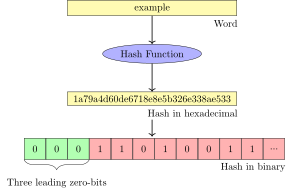

In [6]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=0.5cm, minimum height=0.5cm, text centered, text width=0.3cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (word) [rectangle, text centered, minimum width=6cm, draw=black, fill=yellow!30] {example};
	%\node (t1) [anchor=west, below left=0.2 of word.south west, label={right,align=left:{Word}}] {};
	\node (t1) [anchor=east, below right=0.2 of word.south east, label={left,align=left:{Word}}] {};

	\node (hash) [ellipse, text centered, draw=black, fill=blue!30, below=1 of word] {Hash Function};
	\draw[->,thick] (word) -- (hash);

	\node (hexdigest) [rectangle, text centered, minimum width=6cm, draw=black, fill=yellow!30, below=1 of hash] {1a79a4d60de6718e8e5b326e338ae533};
	\node (t2) [anchor=east, below right=0.2 of hexdigest.south east, label={left,align=left:{Hash in hexadecimal}}] {};
	\draw[->,thick] (hash) -- (hexdigest);

	\node (b0) [box, fill=green!30] at (-4.15,-5) {0};
	\node (b1) [box, fill=green!30, right=0 of b0] {0};
	\node (b2) [box, fill=green!30, right=0 of b1] {0};
	\node (b3) [box, fill=red!30, right=0 of b2] {1};
	\node (b4) [box, fill=red!30, right=0 of b3] {1};
	\node (b5) [box, fill=red!30, right=0 of b4] {0};
	\node (b6) [box, fill=red!30, right=0 of b5] {1};
	\node (b7) [box, fill=red!30, right=0 of b6] {0};
	\node (b8) [box, fill=red!30, right=0 of b7] {0};
	\node (b9) [box, fill=red!30, right=0 of b8] {1};
	\node (b10) [box, fill=red!30, right=0 of b9] {1};
	\node (b11) [box, fill=red!30, right=0 of b10] {...};
	\node (t3) [anchor=east, below right=0.2 of b11.south east, label={left,align=left:{Hash in binary}}] {};

	\draw[->,thick] (hexdigest.south) ++ (0,-0.5) -- ++(0,-0.6);
	\draw [decorate,decoration={brace,amplitude=10pt}, yshift = -0.2cm] (b2.south east) -- (b0.south west) node (curly)[black,midway,xshift = 0.0 cm] {};

	\node (t3) [anchor=center, below=0.7 of b1.south, label={center,align=center:{Three leading zero-bits}}] {};
	
\end{tikzpicture}

We'll keep track of the highest number of leading zero-bits we've seen $b$, and report as our answer $2^b$ unique usernames.

That's it?? Why on Earth does that work?

Well, consider that for a random 128-bit number (what MD5 returns) it's a coin flip whether the first bit will be a $0$ or $1$, so we should expect to see a leading zero $50\%$ of the time. We should therefore expect to see two leading zeroes about $25\%$ of the time, three leading zeroes $12.5\%$ of the time, and so on:

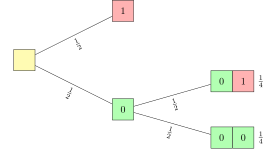

In [7]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=0.5cm, minimum height=0.5cm, text centered, text width=0.3cm, draw=black, fill=yellow!30]
\tikzstyle{end} = [circle, minimum width=3pt,fill, inner sep=0pt]

% Set the overall layout of the tree
\tikzstyle{level 1}=[level distance=3.5cm, sibling distance=3.5cm]
\tikzstyle{level 2}=[level distance=3.5cm, sibling distance=2cm]

\begin{tikzpicture}[grow=right, sloped]
\node[box] {}
    child {
        node[box,fill=green!30] {0}        
            child {
                node (b0) [box,fill=green!30] {0}
                node[box,fill=green!30,right=0 of b0, label=right:{$\frac{1}{4}$}] {0}
                edge from parent
                node[below]  {$\frac{1}{2}$}
            }
            child {
                node (b1) [box,fill=green!30] {0}
                node[box,fill=red!30,right=0 of b1, label=right:{$\frac{1}{4}$}] {1}
                edge from parent
                node[below]  {$\frac{1}{2}$}
            }
            edge from parent 
            node[below]  {$\frac{1}{2}$}
    }
    child {
        node[box,fill=red!30] {1}        
        edge from parent         
            node[below]  {$\frac{1}{2}$}
    };

\end{tikzpicture}

Your turn! Implement probabilistic counting, given the following starter code:

In [ ]:
import random, string

# Yields 'n' random strings of length ten
def generateRandomStrings(n):
	strings = []
	for i in range(0, n):
		strings.append(''.join(random.choices(string.ascii_lowercase, k=10)))
	return strings

# MD5 digest as text bitstring, returns a string of zeroes and ones
def hashBits(term):
	bitstring = ""
	digest = hashlib.md5(term.encode("utf-8")).digest()
	for byte in digest:
		bits = bin(byte)[2:].rjust(8, "0")
		bitstring += bits
	return bitstring

# Takes a list of inputs, estimates the number of unique elements
def probabilisticCounting(inputs):
    pass 

Xs = []
Ys = []
runs = 50
for n in tqdm(np.linspace(1, 10000, 50, dtype=int), desc="Calculating..."):
    Xrun = []
    Yrun = []
    for run in range(runs):
        inputs = generateRandomStrings(n)
        true_unique = len(set(inputs))
        estimated_unique = probabilisticCounting(inputs)
        Xrun.append(true_unique)
        Yrun.append(estimated_unique)
    Xs.append(np.mean(Xrun))
    Ys.append(np.mean(Yrun))
plt.plot(Xs, Ys)
plt.ylim(0, 10000)
plt.show()

#### Reference Solution

Calculating...:   0%|          | 0/50 [00:00<?, ?it/s]

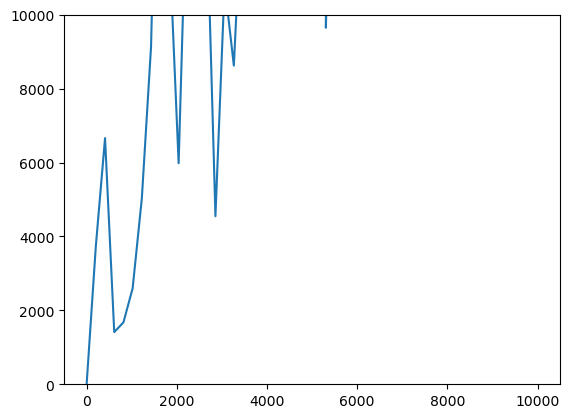

In [5]:
import random, string

# Yields 'n' random strings of length ten
def generateRandomStrings(n):
	strings = []
	for i in range(0, n):
		strings.append(''.join(random.choices(string.ascii_lowercase, k=10)))
	return strings

# MD5 digest as text bitstring, returns a string of zeroes and ones
def hashBits(term):
	bitstring = ""
	digest = hashlib.md5(term.encode("utf-8")).digest()
	for byte in digest:
		bits = bin(byte)[2:].rjust(8, "0")
		bitstring += bits
	return bitstring

# Returns number of leading 0s in a bitstring
def leadingZeros(bitstring):
	leading = 0
	for bit in bitstring:
		if bit == "0":
			leading += 1
		else:
			return leading
	return leading

# Takes a list of inputs, estimates the number of unique elements
def probabilisticCounting(inputs):
    leading_zeroes = 0
    for term in inputs:
        zeroes = leadingZeros(hashBits(term))
        leading_zeroes = max(leading_zeroes,zeroes)
    return 2 ** leading_zeroes

Xs = []
Ys = []
runs = 50
for n in tqdm(np.linspace(1, 10000, 50, dtype=int), desc="Calculating..."):
    Xrun = []
    Yrun = []
    for run in range(runs):
        inputs = generateRandomStrings(n)
        true_unique = len(set(inputs))
        estimated_unique = probabilisticCounting(inputs)
        Xrun.append(true_unique)
        Yrun.append(estimated_unique)
    Xs.append(np.mean(Xrun))
    Ys.append(np.mean(Yrun))
plt.plot(Xs, Ys)
plt.ylim(0, 10000)
plt.show()

This kinda sorta looks like it's working at first, but then probabilistic counting goes off the rails and over-estimates the size. Why??

#### Takeaway

Probabilistic counting is very outlier prone - if a hash gets 'lucky' and has more leading zeros than we'd expect then we'll over-estimate the true number of unique elements. Because we're taking the maximum rather than, say, the median, this metric is extremely outlier sensitive. How can we improve on it?

A clumsy first step is just running the algorithm multiple times and taking the median:

Calculating...:   0%|          | 0/50 [00:00<?, ?it/s]

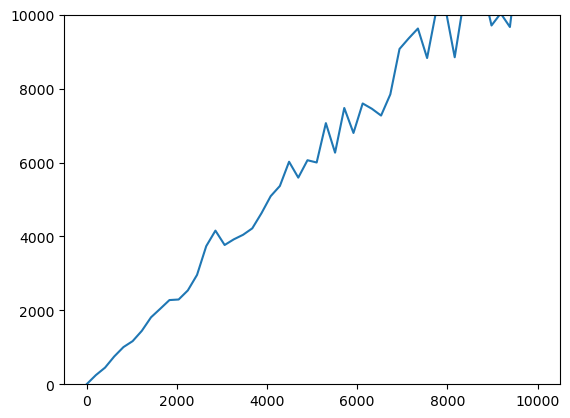

In [6]:
# Calculates ten hashes per string, an expected number of unique values
# based on each hash function, then returns median of those estimates
def probabilisticCountAveraged(terms):
	answers = []
	for salt in ["", "0", "1", "2", "3", "4", "5", "6", "7", "8"]:
		leading_zeros = 0
		for term in terms:
			zeros = leadingZeros(hashBits(term+salt))
			leading_zeros = max(leading_zeros, zeros)
		answers.append(2**leading_zeros)
	return np.median(answers)

Xs = []
Ys = []
runs = 50
for n in tqdm(np.linspace(1, 10000, 50, dtype=int), desc="Calculating..."):
    Xrun = []
    Yrun = []
    for run in range(runs):
        inputs = generateRandomStrings(n)
        true_unique = len(set(inputs))
        estimated_unique = probabilisticCountAveraged(inputs)
        Xrun.append(true_unique)
        Yrun.append(estimated_unique)
    Xs.append(np.mean(Xrun))
    Ys.append(np.mean(Yrun))
plt.plot(Xs, Ys)
plt.ylim(0, 10000)
plt.show()

This is much better! Not only does averaging improve accuracy, but it also improves precision: with a single round of probabilistic counting we can only estimate $2^4$ or $2^5$ elements, but by average across multiple runs we can estimate $2^{4.5}$ elements, or about 23. However, this approach is also ten times slower, and it's _still_ over-estimating the number of unique elements, just not as badly. 

#### HyperLogLog

What if instead of running ten different hash functions on all the inputs, we pre-allocate hashes into a number of "buckets," take the average answer across each bucket, and use _that_ to predict the number of unique elements?

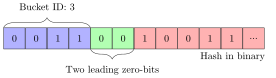

In [7]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=0.5cm, minimum height=0.5cm, text centered, text width=0.3cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (b0) [box, fill=blue!30] {0};
	\node (b1) [box, fill=blue!30, right=0 of b0] {0};
	\node (b2) [box, fill=blue!30, right=0 of b1] {1};
	\node (b3) [box, fill=blue!30, right=0 of b2] {1};
	\node (b4) [box, fill=green!30, right=0 of b3] {0};
	\node (b5) [box, fill=green!30, right=0 of b4] {0};
	\node (b6) [box, fill=red!30, right=0 of b5] {1};
	\node (b7) [box, fill=red!30, right=0 of b6] {0};
	\node (b8) [box, fill=red!30, right=0 of b7] {0};
	\node (b9) [box, fill=red!30, right=0 of b8] {1};
	\node (b10) [box, fill=red!30, right=0 of b9] {1};
	\node (b11) [box, fill=red!30, right=0 of b10] {...};
	\node (t3) [anchor=east, below right=0.2 of b11.south east, label={left,align=left:{Hash in binary}}] {};

	\draw [decorate,decoration={brace,amplitude=10pt}, yshift = -0.2cm] (b0.north west) -- (b3.north east) node (curly1)[black,midway,xshift = 0.0 cm] {};
	\draw [decorate,decoration={brace,amplitude=10pt}, yshift = -0.2cm] (b5.south east) -- (b4.south west) node (curly2)[black,midway,xshift = 0.0 cm] {};

	%\node (t3) [anchor=center, below=0.7 of b1.south, label={center,align=center:{Three leading zero-bits}}] {};
	\node (t0) [anchor=center, above=0.5 of curly1, label={center,align=center:{Bucket ID: 3}}] {};
	\node (t1) [anchor=center, below=0.5 of curly2, label={center,align=center:{Two leading zero-bits}}] {};
	
\end{tikzpicture}

We'll use the first four bits to decide what bucket the input goes in, and then count the leading zeroes in the remainder of the hash, skipping the bucket ID.

Do you foresee any challenges with this strategy?

Because each bucket now has fewer elements in it, most buckets will _under_-estimate the number of unique elements. We need to use an average instead of a maximum to compensate for outliers. But can we also compensate for the depreciation of the unique value count? Yes!

$$\begin{align}
Z &= \left( \sum_{j=1}^{m} 2^{-M_j} \right)^{-1} && \text{Harmonic mean across $m$ buckets} \\
\alpha_m &= \left( m \int_0^{\infty} \left( \log_2 \left(\frac{2+u}{1+u}\right)\right)^m du\right)^{-1} && \text{Compensation factor} \\
E &= \alpha_m m^2 Z && \text{Final estimate} \\
\end{align}
$$

The estimation term is awful, so we usually just use a lookup table and rough heuristic to estimate it:

$$
\alpha_m \approx \begin{cases}
    0.673 && \text{For $m=16$} \\
    0.697 && \text{For $m=32$} \\
    0.709 && \text{For $m=64$} \\
    \frac{0.7213}{1+1.079/m} && \text{For $m \geq 128$}
\end{cases}
$$

Your turn! Implement hyperloglog -- you may use a fixed number of bins and compensation factor to simplify.

Calculating...:   0%|          | 0/50 [00:00<?, ?it/s]

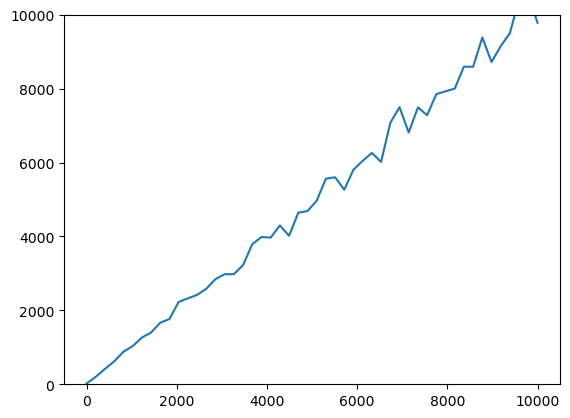

In [8]:
def hyperLogLog(terms, binbits=4):
	bincount = 2**binbits
	bins = [0]*bincount
	for term in terms:
		bitstring = hashBits(term)
		binIndex = int(bitstring[0:binbits], 2)
		zeros = leadingZeros(bitstring[binbits:])
		bins[binIndex] = max(bins[binIndex], zeros)
	# Returns magic number to boost estimates based on deflation from bincount	
	def binCompensator(bins):
		try:
			return {16: 0.673, 32: 0.697, 64: 0.709}[bins]
		except KeyError:
			if( bins >= 128 ):
				return 0.7212 / (1 + 1.079/bins)
			raise ValueError("Invalid number of bins -- minimum 16")
	def harmonicAverage(bins):
		return sum(map(lambda b: 2**(-1*(1+b)), bins)) ** -1
	return binCompensator(bincount) * (bincount**2) * harmonicAverage(bins)

Xs = []
Ys = []
runs = 50
for n in tqdm(np.linspace(1, 10000, 50, dtype=int), desc="Calculating..."):
    Xrun = []
    Yrun = []
    for run in range(runs):
        inputs = generateRandomStrings(n)
        true_unique = len(set(inputs))
        estimated_unique = hyperLogLog(inputs)
        Xrun.append(true_unique)
        Yrun.append(estimated_unique)
    Xs.append(np.mean(Xrun))
    Ys.append(np.mean(Yrun))
plt.plot(Xs, Ys)
plt.ylim(0, 10000)
plt.show()

To save us time, I've pre-rendered a comparison of the three approaches with nice error bars for comparison:

![HyperLogLog Performance](images/hyperloglog.png)

The accuracy here still isn't perfect, and the error bars _do_ get wider as the number of unique elements increase. However, if you know the precision of your final result will be limited ("We had 3.2 billion users sign in last month"), then you can get a result precise enough that those error bars are irrelevant.

Note also that by increasing the number of bins you can increase precision for large counts of unique elements, at the cost of _lower_ precision for small numbers of elements. So if you know your answer will be in the billions, perhaps you want to set 128 bins instead of 4.

----

### Bloom Filters

Hyperloglog lets us estimate the size of a set without storing all its contents. What if we want to estimate _membership_ in a set? Did a particular user _maybe_ log in this month? We can construct a special kind of probabilistic set called a _Bloom Filter_ that can tells us definitive "no" and "maybe."

Before we get into the "how" let's start with "why?"

Bloom filters have a number of applications:

* Pre-cache for web browsers
* Pre-cache for database queries
* Tracking novel content for social media feeds
* Edge detection on enormous sparse graphs

In all cases, getting a definitive answer is computationally expensive, and the answer is usually _no._ Bloom filters are computationally and memory cheap, and let us easily filter out most of those "no's", only executing the expensive query when there's likely to be a result.

To expand on the last example: an adjacency matrix has $O(1)$ lookup, but requires $O(V^2)$ memory. Because most large graphs are sparse, we store a sparse adjacency matrix, which like an edge list has roughly $O(E)$ lookup but only $O(E)$ memory. If we're querying "is there an edge between $A$ and $B$" and the graph is sparse, then the answer will usually be "no." Bloom filters can give us a definitive "no" in $O(1)$ time, and then we can query the sparse matrix only for edges that we're fairly confident might exist.

To create a bloom filter we first decide on a size (in this example, $m=10$) and a number of hash functions (in this example, $k=3$). To add an element to the bloom filter we simply hash it with all $k$ hash functions, use modular arithmetic to find corresponding bits, and set those bits to one:

In [20]:
from binascii import crc32

k = 3
m = 10
bloom_filter_bits = np.zeros(m, dtype=int)

def bloomHash(element, i):
    term = element + str(i)
    """
    You could do this with md5 to match the HyperLogLog example, 
    but it's slower and slightly more complicated and will put
    bits in different places than in my diagrams. Instead we'll
    use CRC32, a quick checksum.
    """
    #digest = hashlib.md5(term.encode("utf-8")).hexdigest()
    #return int.from_bytes(bytes.fromhex(digest), "little", signed=True)
    return crc32((str(i) + element).encode("utf-8"))

def add(element):
    for i in range(k):
        bin_ = bloomHash(element, i) % m
        bloom_filter_bits[bin_] = 1

print(bloom_filter_bits)
add("swordfish")
print(bloom_filter_bits)
add("sunfish")
print(bloom_filter_bits)

[0 0 0 0 0 0 0 0 0 0]
[0 0 1 1 0 0 0 1 0 0]
[0 0 1 1 0 0 1 1 0 1]


In [3]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=0.5cm, minimum height=0.5cm, text centered, text width=0.3cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (b0) [box] {0};
	\node (b1) [box, right=0 of b0] {0};
	\node (b2) [box, fill=blue!30, right=0 of b1] {1};
	\node (b3) [box, fill=blue!30, right=0 of b2] {1};
	\node (b4) [box, right=0 of b3] {0};
	\node (b5) [box, right=0 of b4] {0};
	\node (b6) [box, fill=blue!30, right=0 of b5] {1};
	\node (b7) [box, fill=blue!30, right=0 of b6] {1};
	\node (b8) [box, right=0 of b7] {0};
	\node (b9) [box, fill=blue!30, right=0 of b8] {1};
	\node (t1) [anchor=east, below right=0.2 of b9.south east, label={left,align=left:{Bloom filter bits}}] {};

	\node (e0) [rectangle, text centered, minimum width=3cm, draw=black, fill=cyan!30] at (1.5,2) {swordfish};
	\node (e1) [rectangle, text centered, minimum width=3cm, draw=black, fill=red!30] at (5.5,2) {sunfish};

	\draw[->,thick,cyan!30] (e0.south) to [out=270,in=90] (b2.north);
	\draw[->,thick,cyan!30] (e0.south) to [out=270,in=90] (b3.north);
	\draw[->,thick,cyan!30] (e0.south) to [out=270,in=90] (b7.north);

	\draw[->,thick,red!30] (e1.south) to [out=270,in=90] (b3.north);
	\draw[->,thick,red!30] (e1.south) to [out=270,in=90] (b6.north);
	\draw[->,thick,red!30] (e1.south) to [out=270,in=90] (b9.north);

	% set 2,3,6,7,9

	% salmon 156

\end{tikzpicture}

'pdflatex' is not recognized as an internal or external command,
operable program or batch file.


To query whether an element _may_ be in the bloom filter we just hash it with all $k$ hash functions, and check whether all the corresponding bits are set to 1. If they are, then _either_ the element is in the set, _or_ other elements in the set have set all those same bits to 1. However, if any of the corresponding bits are set to 0, the element _cannot_ be in the set.

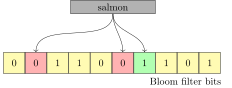

In [16]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=0.5cm, minimum height=0.5cm, text centered, text width=0.3cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (b0) [box] {0};
	\node (b1) [box, fill=red!30, right=0 of b0] {0};
	\node (b2) [box, right=0 of b1] {1};
	\node (b3) [box, right=0 of b2] {1};
	\node (b4) [box, right=0 of b3] {0};
	\node (b5) [box, fill=red!30, right=0 of b4] {0};
	\node (b6) [box, fill=green!30, right=0 of b5] {1};
	\node (b7) [box, right=0 of b6] {1};
	\node (b8) [box, right=0 of b7] {0};
	\node (b9) [box, right=0 of b8] {1};
	\node (t1) [anchor=east, below right=0.2 of b9.south east, label={left,align=left:{Bloom filter bits}}] {};

	\node (e0) [anchor=center, rectangle, text centered, minimum width=3cm, draw=black, fill=black!30] at (3.5,2) {salmon};

	\draw[->] (e0.south) to [out=270,in=90] (b1.north);
	\draw[->] (e0.south) to [out=270,in=90] (b5.north);
	\draw[->] (e0.south) to [out=270,in=90] (b6.north);

	% set 2,3,6,7,9

	% salmon 156

\end{tikzpicture}

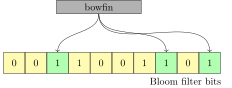

In [17]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\tikzstyle{box} = [regular polygon, regular polygon sides=4, minimum width=0.5cm, minimum height=0.5cm, text centered, text width=0.3cm, draw=black, fill=yellow!30]

\begin{tikzpicture}[]

	\node (b0) [box] {0};
	\node (b1) [box, right=0 of b0] {0};
	\node (b2) [box, fill=green!30, right=0 of b1] {1};
	\node (b3) [box, right=0 of b2] {1};
	\node (b4) [box, right=0 of b3] {0};
	\node (b5) [box, right=0 of b4] {0};
	\node (b6) [box, right=0 of b5] {1};
	\node (b7) [box, fill=green!30, right=0 of b6] {1};
	\node (b8) [box, right=0 of b7] {0};
	\node (b9) [box, fill=green!30, right=0 of b8] {1};
	\node (t1) [anchor=east, below right=0.2 of b9.south east, label={left,align=left:{Bloom filter bits}}] {};

	\node (e0) [rectangle, text centered, minimum width=3cm, draw=black, fill=black!30] at (3,2) {bowfin};

	\draw[->] (e0.south) to [out=270,in=90] (b2.north);
	\draw[->] (e0.south) to [out=270,in=90] (b7.north);
	\draw[->] (e0.south) to [out=270,in=90] (b9.north);

	% set 2,3,6,7,9

	% salmon 156

\end{tikzpicture}

#### Design Tradeoffs

When enough elements are added to the bloom filter many bits will become 1, and our false-positive rate will skyrocket, rendering the filter largely useless.

The more bits ($m$) in the bloom filter, the more elements we can add before filling it. However, increasing $m$ directly increases memory usage.

The more hash functions we add ($k$) the fewer false-positives we'll get, and so the more useful our bloom filter will be. However, more hash functions will also fill the bloom filter faster, necessitating a higher $m$.

If we know about how many elements we're going to want, then we can select an optimal $k$ and $m$ based on the desired false-positive rate $\epsilon$:

$$k = -\log_2 \epsilon$$

$$m = - \frac{n \ln \epsilon}{(\ln 2)^2}$$

![](images/observed_false_positive_rate_k.png)

![](images/observed_false_positive_rate_m.png)

----

Hard pivot to...

### Cluster Computing

Sometimes approximation algorithms and subsampling aren't valid options. In the space of networks, this comes up frequently in two cases:

1. I want to run many small simulations (either on a fixed network, or by generating many networks)
2. I have a gargantuan network and want to take measurements or run a simulation

When there's too much work for your CPU, we have two options:

1. Use the GPU
2. Use a cluster computer

The GPU has thousands of times more cores than your CPU, and can run many operations in parallel. However, the cores are not independent or general purpose - they're ideal for tasks like "multiply these two large matrices together," where you can perform multiply and add operations to tens of thousands of arguments at a time. This kind of workload is common in computer graphics, parts of machine learning (especially in training and evaluating neural networks), and parts of network science!

There are network packages like [cuGraph](https://github.com/rapidsai/cugraph) (and its networkx integration, [nx-cugraph](https://rapids.ai/nx-cugraph/)) that implement common algorithms like PageRank on the GPU, or AllegroLayout (RIP) that implement force-directed graph layouts on the GPU; both can allow you to work with larger graph data faster than networkx, igraph, or graph-tool can allow.

But these tools are limited to a handful of specific algorithms that are amenable to GPU programming. What about in more general cases? Now we turn to cluster computing. So first...

#### What is a Supercomputer, Anyway?

Cluster computers, colloquially referred to as "supercomputers," are many computers interconnected to share resources. Some of their resources are transparently combined, typically the filesystem, so you'll see several petabytes of storage that's actually split across many drives on many computers. However, a cluster computer does _not_ act like one big computer.

Instead, you submit jobs that run on a subset of the computers in the cluster, who may communicate among themselves. Clusters can be structured in a variety of ways to facilitate different patterns of communicate, ranging from a fat tree (what Northeastern's Explorer cluster uses _I think_):

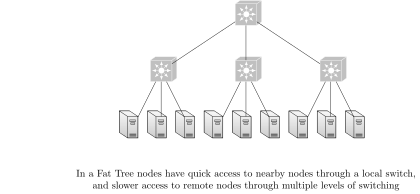

In [21]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\definecolor{switch}{HTML}{c0c0c0}

\makeatletter
\pgfkeys{/pgf/.cd,
  parallelepiped offset x/.initial=2mm,
  parallelepiped offset y/.initial=2mm
}
\pgfdeclareshape{parallelepiped}
{
  \inheritsavedanchors[from=rectangle] % this is nearly a rectangle
  \inheritanchorborder[from=rectangle]
  \inheritanchor[from=rectangle]{north}
  \inheritanchor[from=rectangle]{north west}
  \inheritanchor[from=rectangle]{north east}
  \inheritanchor[from=rectangle]{center}
  \inheritanchor[from=rectangle]{west}
  \inheritanchor[from=rectangle]{east}
  \inheritanchor[from=rectangle]{mid}
  \inheritanchor[from=rectangle]{mid west}
  \inheritanchor[from=rectangle]{mid east}
  \inheritanchor[from=rectangle]{base}
  \inheritanchor[from=rectangle]{base west}
  \inheritanchor[from=rectangle]{base east}
  \inheritanchor[from=rectangle]{south}
  \inheritanchor[from=rectangle]{south west}
  \inheritanchor[from=rectangle]{south east}
  \backgroundpath{
    % store lower right in xa/ya and upper right in xb/yb
    \southwest \pgf@xa=\pgf@x \pgf@ya=\pgf@y
    \northeast \pgf@xb=\pgf@x \pgf@yb=\pgf@y
    \pgfmathsetlength\pgfutil@tempdima{\pgfkeysvalueof{/pgf/parallelepiped
      offset x}}
    \pgfmathsetlength\pgfutil@tempdimb{\pgfkeysvalueof{/pgf/parallelepiped
      offset y}}
    \def\ppd@offset{\pgfpoint{\pgfutil@tempdima}{\pgfutil@tempdimb}}
    \pgfpathmoveto{\pgfqpoint{\pgf@xa}{\pgf@ya}}
    \pgfpathlineto{\pgfqpoint{\pgf@xb}{\pgf@ya}}
    \pgfpathlineto{\pgfqpoint{\pgf@xb}{\pgf@yb}}
    \pgfpathlineto{\pgfqpoint{\pgf@xa}{\pgf@yb}}
    \pgfpathclose
    \pgfpathmoveto{\pgfqpoint{\pgf@xb}{\pgf@ya}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@ya}}{\ppd@offset}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@yb}}{\ppd@offset}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xa}{\pgf@yb}}{\ppd@offset}}
    \pgfpathlineto{\pgfqpoint{\pgf@xa}{\pgf@yb}}
    \pgfpathmoveto{\pgfqpoint{\pgf@xb}{\pgf@yb}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@yb}}{\ppd@offset}}
  }
}
\makeatother

\begin{tikzpicture}[ports/.style={
    line width=0.3pt,
    top color=gray!20,
    bottom color=gray!80
  },
switch/.style={
    parallelepiped,fill=switch, draw=white,
    minimum width=0.75cm,
    minimum height=0.75cm,
    parallelepiped offset x=1.75mm,
    parallelepiped offset y=1.25mm,
    path picture={
      \node[fill=white,
        circle,
        minimum size=6pt,
        inner sep=0pt,
        append after command={
          \pgfextra{
            \foreach \angle in {0,45,...,360}
            \draw[-latex,fill=white] (\tikzlastnode.\angle)--++(\angle:2.25mm);
          }
        }
      ] 
       at ([xshift=-0.75mm,yshift=-0.5mm]path picture bounding box.center){};
    }
  },
	server/.style={
    parallelepiped,
    fill=white, draw,
    minimum width=0.35cm,
    minimum height=0.75cm,
    parallelepiped offset x=3mm,
    parallelepiped offset y=2mm,
    xscale=-1,
    path picture={
      \draw[top color=gray!5,bottom color=gray!40]
      (path picture bounding box.south west) rectangle 
      (path picture bounding box.north east);
      \coordinate (A-center) at ($(path picture bounding box.center)!0!(path
        picture bounding box.south)$);
      \coordinate (A-west) at ([xshift=-0.575cm]path picture bounding box.west);
      \draw[ports]([yshift=0.1cm]$(A-west)!0!(A-center)$)
        rectangle +(0.2,0.065);
      \draw[ports]([yshift=0.01cm]$(A-west)!0.085!(A-center)$)
        rectangle +(0.15,0.05);
      \fill[black]([yshift=-0.35cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
      \fill[black]([yshift=-0.385cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
      \fill[black]([yshift=-0.42cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
    }  
  },
  myarrow/.style={-Stealth},
  node distance=0.6cm and 1.2cm
  ]
  
  %\node[server] (a) {};
  %\node[server, above right=1 of a] (b) {};
  %\node[server, right=1 of b] (c) {};
  %\node[server, below right=1 of c] (d) {};
  %\node (midpoint) at ($(b)!0.5!(c)$) {};
  %\node[server, below=3 of midpoint] (e) {};

  %\node[switch] at 

  \node[server] at (0,0) (a0) {};
  \node[server] at (1,0) (a1) {};
  \node[server] at (2,0) (a2) {};
  \node[server] at (3,0) (a3) {};
  \node[server] at (4,0) (a4) {};
  \node[server] at (5,0) (a5) {};
  \node[server] at (6,0) (a6) {};
  \node[server] at (7,0) (a7) {};
  \node[server] at (8,0) (a8) {};

  \node[switch] at (1,2) (s1) {};
  \node[switch] at (4,2) (s2) {};
  \node[switch] at (7,2) (s3) {};

  \node[switch] at (4,4) (parent) {};

  \draw[-] (a0) -- (s1);
  \draw[-] (a1) -- (s1);
  \draw[-] (a2) -- (s1);

  \draw[-] (a3) -- (s2);
  \draw[-] (a4) -- (s2);
  \draw[-] (a5) -- (s2);

  \draw[-] (a6) -- (s3);
  \draw[-] (a7) -- (s3);
  \draw[-] (a8) -- (s3);

  \draw[-] (s1) -- (parent);
  \draw[-] (s2) -- (parent);
  \draw[-] (s3) -- (parent);

  \draw node[anchor=north,below=1 of a4,align=center] {In a Fat Tree nodes have quick access to nearby nodes through a local switch,\\and slower access to remote nodes through multiple levels of switching};

\end{tikzpicture}

To a torus (IBM BlueGene supercomputers -- what I learned on):

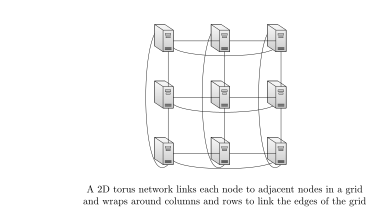

In [22]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\pgfdeclarelayer{bg}    % declare background layer
\pgfsetlayers{bg,main}  % set the order of the layers (main is the standard layer)

\definecolor{switch}{HTML}{c0c0c0}

\makeatletter
\pgfkeys{/pgf/.cd,
  parallelepiped offset x/.initial=2mm,
  parallelepiped offset y/.initial=2mm
}
\pgfdeclareshape{parallelepiped}
{
  \inheritsavedanchors[from=rectangle] % this is nearly a rectangle
  \inheritanchorborder[from=rectangle]
  \inheritanchor[from=rectangle]{north}
  \inheritanchor[from=rectangle]{north west}
  \inheritanchor[from=rectangle]{north east}
  \inheritanchor[from=rectangle]{center}
  \inheritanchor[from=rectangle]{west}
  \inheritanchor[from=rectangle]{east}
  \inheritanchor[from=rectangle]{mid}
  \inheritanchor[from=rectangle]{mid west}
  \inheritanchor[from=rectangle]{mid east}
  \inheritanchor[from=rectangle]{base}
  \inheritanchor[from=rectangle]{base west}
  \inheritanchor[from=rectangle]{base east}
  \inheritanchor[from=rectangle]{south}
  \inheritanchor[from=rectangle]{south west}
  \inheritanchor[from=rectangle]{south east}
  \backgroundpath{
    % store lower right in xa/ya and upper right in xb/yb
    \southwest \pgf@xa=\pgf@x \pgf@ya=\pgf@y
    \northeast \pgf@xb=\pgf@x \pgf@yb=\pgf@y
    \pgfmathsetlength\pgfutil@tempdima{\pgfkeysvalueof{/pgf/parallelepiped
      offset x}}
    \pgfmathsetlength\pgfutil@tempdimb{\pgfkeysvalueof{/pgf/parallelepiped
      offset y}}
    \def\ppd@offset{\pgfpoint{\pgfutil@tempdima}{\pgfutil@tempdimb}}
    \pgfpathmoveto{\pgfqpoint{\pgf@xa}{\pgf@ya}}
    \pgfpathlineto{\pgfqpoint{\pgf@xb}{\pgf@ya}}
    \pgfpathlineto{\pgfqpoint{\pgf@xb}{\pgf@yb}}
    \pgfpathlineto{\pgfqpoint{\pgf@xa}{\pgf@yb}}
    \pgfpathclose
    \pgfpathmoveto{\pgfqpoint{\pgf@xb}{\pgf@ya}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@ya}}{\ppd@offset}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@yb}}{\ppd@offset}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xa}{\pgf@yb}}{\ppd@offset}}
    \pgfpathlineto{\pgfqpoint{\pgf@xa}{\pgf@yb}}
    \pgfpathmoveto{\pgfqpoint{\pgf@xb}{\pgf@yb}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@yb}}{\ppd@offset}}
  }
}
\makeatother

\begin{tikzpicture}[ports/.style={
    line width=0.3pt,
    top color=gray!20,
    bottom color=gray!80
  },
switch/.style={
    parallelepiped,fill=switch, draw=white,
    minimum width=0.75cm,
    minimum height=0.75cm,
    parallelepiped offset x=1.75mm,
    parallelepiped offset y=1.25mm,
    path picture={
      \node[fill=white,
        circle,
        minimum size=6pt,
        inner sep=0pt,
        append after command={
          \pgfextra{
            \foreach \angle in {0,45,...,360}
            \draw[-latex,fill=white] (\tikzlastnode.\angle)--++(\angle:2.25mm);
          }
        }
      ] 
       at ([xshift=-0.75mm,yshift=-0.5mm]path picture bounding box.center){};
    }
  },
	server/.style={
    parallelepiped,
    fill=white, draw,
    minimum width=0.35cm,
    minimum height=0.75cm,
    parallelepiped offset x=3mm,
    parallelepiped offset y=2mm,
    xscale=-1,
    path picture={
      \draw[top color=gray!5,bottom color=gray!40]
      (path picture bounding box.south west) rectangle 
      (path picture bounding box.north east);
      \coordinate (A-center) at ($(path picture bounding box.center)!0!(path
        picture bounding box.south)$);
      \coordinate (A-west) at ([xshift=-0.575cm]path picture bounding box.west);
      \draw[ports]([yshift=0.1cm]$(A-west)!0!(A-center)$)
        rectangle +(0.2,0.065);
      \draw[ports]([yshift=0.01cm]$(A-west)!0.085!(A-center)$)
        rectangle +(0.15,0.05);
      \fill[black]([yshift=-0.35cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
      \fill[black]([yshift=-0.385cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
      \fill[black]([yshift=-0.42cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
    }  
  },
  myarrow/.style={-Stealth},
  node distance=0.6cm and 1.2cm
  ]
  
  %\node[server] (a) {};
  %\node[server, above right=1 of a] (b) {};
  %\node[server, right=1 of b] (c) {};
  %\node[server, below right=1 of c] (d) {};
  %\node (midpoint) at ($(b)!0.5!(c)$) {};
  %\node[server, below=3 of midpoint] (e) {};

  %\node[switch] at 

  \node[server] at (0,0,0) (b0) {};
  \node[server] at (2,0,0) (b1) {};
  \node[server] at (4,0,0) (b2) {};
  \node[server] at (0,2,0) (b3) {};
  \node[server] at (0,4,0) (b4) {};
  \node[server] at (2,2,0) (b5) {};
  \node[server] at (2,4,0) (b6) {};
  \node[server] at (4,2,0) (b7) {};
  \node[server] at (4,4,0) (b8) {};

  % Rows first
  \draw[-] (b0) -- (b1);
  \draw[-] (b1) -- (b2);
  \draw[-] (b3) -- (b5);
  \draw[-] (b5) -- (b7);
  \draw[-] (b4) -- (b6);
  \draw[-] (b6) -- (b8);

  % Now fill in the columns
  \draw[-] (b0) -- (b3);
  \draw[-] (b3) -- (b4);
  \draw[-] (b1) -- (b5);
  \draw[-] (b5) -- (b6);
  \draw[-] (b2) -- (b7);
  \draw[-] (b7) -- (b8);

  % And now the wraparound edges
  \begin{pgfonlayer}{bg}    % select the background layer
    % Rows first
    \draw[-] (b0.west) to[out=south west,in=south east, distance=1cm] (b2.east);
    \draw[-] (b3.west) to[out=south west,in=south east, distance=1cm] (b7.east);
    \draw[-] (b4.west) to[out=south west,in=south east, distance=1cm] (b8.east);

	% Now columns
    \draw[-] (b0.south) to[out=south west,in=north west, distance=1.5cm] (b4.north);
    \draw[-] (b1.south) to[out=south west,in=north west, distance=1.5cm] (b6.north);
    \draw[-] (b2.south) to[out=south west,in=north west, distance=1.5cm] (b8.north);
  \end{pgfonlayer}

  %\node[server] at (0,0,4) (t0) {};

  \draw node[anchor=north,align=center] at (2,-1,0) {A 2D torus network links each node to adjacent nodes in a grid\\and wraps around columns and rows to link the edges of the grid};

\end{tikzpicture}


To a butterfly (we love you Cray):

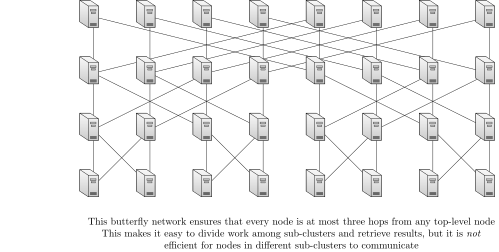

In [23]:
%%tikz -l=positioning,arrows.meta,shapes,shapes.geometric,arrows,shadows,fit,calc,backgrounds,decorations.pathreplacing
\pgfdeclarelayer{bg}    % declare background layer
\pgfsetlayers{bg,main}  % set the order of the layers (main is the standard layer)

\definecolor{switch}{HTML}{c0c0c0}

\makeatletter
\pgfkeys{/pgf/.cd,
  parallelepiped offset x/.initial=2mm,
  parallelepiped offset y/.initial=2mm
}
\pgfdeclareshape{parallelepiped}
{
  \inheritsavedanchors[from=rectangle] % this is nearly a rectangle
  \inheritanchorborder[from=rectangle]
  \inheritanchor[from=rectangle]{north}
  \inheritanchor[from=rectangle]{north west}
  \inheritanchor[from=rectangle]{north east}
  \inheritanchor[from=rectangle]{center}
  \inheritanchor[from=rectangle]{west}
  \inheritanchor[from=rectangle]{east}
  \inheritanchor[from=rectangle]{mid}
  \inheritanchor[from=rectangle]{mid west}
  \inheritanchor[from=rectangle]{mid east}
  \inheritanchor[from=rectangle]{base}
  \inheritanchor[from=rectangle]{base west}
  \inheritanchor[from=rectangle]{base east}
  \inheritanchor[from=rectangle]{south}
  \inheritanchor[from=rectangle]{south west}
  \inheritanchor[from=rectangle]{south east}
  \backgroundpath{
    % store lower right in xa/ya and upper right in xb/yb
    \southwest \pgf@xa=\pgf@x \pgf@ya=\pgf@y
    \northeast \pgf@xb=\pgf@x \pgf@yb=\pgf@y
    \pgfmathsetlength\pgfutil@tempdima{\pgfkeysvalueof{/pgf/parallelepiped
      offset x}}
    \pgfmathsetlength\pgfutil@tempdimb{\pgfkeysvalueof{/pgf/parallelepiped
      offset y}}
    \def\ppd@offset{\pgfpoint{\pgfutil@tempdima}{\pgfutil@tempdimb}}
    \pgfpathmoveto{\pgfqpoint{\pgf@xa}{\pgf@ya}}
    \pgfpathlineto{\pgfqpoint{\pgf@xb}{\pgf@ya}}
    \pgfpathlineto{\pgfqpoint{\pgf@xb}{\pgf@yb}}
    \pgfpathlineto{\pgfqpoint{\pgf@xa}{\pgf@yb}}
    \pgfpathclose
    \pgfpathmoveto{\pgfqpoint{\pgf@xb}{\pgf@ya}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@ya}}{\ppd@offset}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@yb}}{\ppd@offset}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xa}{\pgf@yb}}{\ppd@offset}}
    \pgfpathlineto{\pgfqpoint{\pgf@xa}{\pgf@yb}}
    \pgfpathmoveto{\pgfqpoint{\pgf@xb}{\pgf@yb}}
    \pgfpathlineto{\pgfpointadd{\pgfpoint{\pgf@xb}{\pgf@yb}}{\ppd@offset}}
  }
}
\makeatother

\begin{tikzpicture}[ports/.style={
    line width=0.3pt,
    top color=gray!20,
    bottom color=gray!80
  },
switch/.style={
    parallelepiped,fill=switch, draw=white,
    minimum width=0.75cm,
    minimum height=0.75cm,
    parallelepiped offset x=1.75mm,
    parallelepiped offset y=1.25mm,
    path picture={
      \node[fill=white,
        circle,
        minimum size=6pt,
        inner sep=0pt,
        append after command={
          \pgfextra{
            \foreach \angle in {0,45,...,360}
            \draw[-latex,fill=white] (\tikzlastnode.\angle)--++(\angle:2.25mm);
          }
        }
      ] 
       at ([xshift=-0.75mm,yshift=-0.5mm]path picture bounding box.center){};
    }
  },
	server/.style={
    parallelepiped,
    fill=white, draw,
    minimum width=0.35cm,
    minimum height=0.75cm,
    parallelepiped offset x=3mm,
    parallelepiped offset y=2mm,
    xscale=-1,
    path picture={
      \draw[top color=gray!5,bottom color=gray!40]
      (path picture bounding box.south west) rectangle 
      (path picture bounding box.north east);
      \coordinate (A-center) at ($(path picture bounding box.center)!0!(path
        picture bounding box.south)$);
      \coordinate (A-west) at ([xshift=-0.575cm]path picture bounding box.west);
      \draw[ports]([yshift=0.1cm]$(A-west)!0!(A-center)$)
        rectangle +(0.2,0.065);
      \draw[ports]([yshift=0.01cm]$(A-west)!0.085!(A-center)$)
        rectangle +(0.15,0.05);
      \fill[black]([yshift=-0.35cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
      \fill[black]([yshift=-0.385cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
      \fill[black]([yshift=-0.42cm]$(A-west)!-0.1!(A-center)$)
        rectangle +(0.235,0.0175);
    }  
  },
  myarrow/.style={-Stealth},
  node distance=0.6cm and 1.2cm
  ]
  
  %\node[server] (a) {};
  %\node[server, above right=1 of a] (b) {};
  %\node[server, right=1 of b] (c) {};
  %\node[server, below right=1 of c] (d) {};
  %\node (midpoint) at ($(b)!0.5!(c)$) {};
  %\node[server, below=3 of midpoint] (e) {};

  %\node[switch] at 

  \node[server] at (0,0) (s00) {};
  \node[server] at (2,0) (s01) {};
  \node[server] at (4,0) (s02) {};
  \node[server] at (6,0) (s03) {};
  \node[server] at (8,0) (s04) {};
  \node[server] at (10,0) (s05) {};
  \node[server] at (12,0) (s06) {};
  \node[server] at (14,0) (s07) {};

  \node[server] at (0,-2) (s10) {};
  \node[server] at (2,-2) (s11) {};
  \node[server] at (4,-2) (s12) {};
  \node[server] at (6,-2) (s13) {};
  \node[server] at (8,-2) (s14) {};
  \node[server] at (10,-2) (s15) {};
  \node[server] at (12,-2) (s16) {};
  \node[server] at (14,-2) (s17) {};

  \node[server] at (0,-4) (s20) {};
  \node[server] at (2,-4) (s21) {};
  \node[server] at (4,-4) (s22) {};
  \node[server] at (6,-4) (s23) {};
  \node[server] at (8,-4) (s24) {};
  \node[server] at (10,-4) (s25) {};
  \node[server] at (12,-4) (s26) {};
  \node[server] at (14,-4) (s27) {};

  \node[server] at (0,-6) (s30) {};
  \node[server] at (2,-6) (s31) {};
  \node[server] at (4,-6) (s32) {};
  \node[server] at (6,-6) (s33) {};
  \node[server] at (8,-6) (s34) {};
  \node[server] at (10,-6) (s35) {};
  \node[server] at (12,-6) (s36) {};
  \node[server] at (14,-6) (s37) {};

  % Rows first
  \begin{pgfonlayer}{bg}    % select the background layer
	  \draw[-] (s00) -- (s14);
	  \draw[-] (s01) -- (s15);
	  \draw[-] (s02) -- (s16);
	  \draw[-] (s03) -- (s17);
	  \draw[-] (s04) -- (s10);
	  \draw[-] (s05) -- (s11);
	  \draw[-] (s06) -- (s12);
	  \draw[-] (s07) -- (s13);

	  \draw[-] (s10) -- (s22);
	  \draw[-] (s11) -- (s23);
	  \draw[-] (s12) -- (s20);
	  \draw[-] (s13) -- (s21);
	  \draw[-] (s14) -- (s26);
	  \draw[-] (s15) -- (s27);
	  \draw[-] (s16) -- (s24);
	  \draw[-] (s17) -- (s25);

	  \draw[-] (s20) -- (s31);
	  \draw[-] (s21) -- (s30);
	  \draw[-] (s22) -- (s33);
	  \draw[-] (s23) -- (s32);
	  \draw[-] (s24) -- (s35);
	  \draw[-] (s25) -- (s34);
	  \draw[-] (s26) -- (s37);
	  \draw[-] (s27) -- (s36);

	  \draw[-] (s00) -- (s10) -- (s20) -- (s30);
	  \draw[-] (s01) -- (s11) -- (s21) -- (s31);
	  \draw[-] (s02) -- (s12) -- (s22) -- (s32);
	  \draw[-] (s03) -- (s13) -- (s23) -- (s33);
	  \draw[-] (s04) -- (s14) -- (s24) -- (s34);
	  \draw[-] (s05) -- (s15) -- (s25) -- (s35);
	  \draw[-] (s06) -- (s16) -- (s26) -- (s36);
	  \draw[-] (s07) -- (s17) -- (s27) -- (s37);

  \end{pgfonlayer}

  \draw node[anchor=north,align=center] at (7,-7) {This butterfly network ensures that every node is at most three hops from any top-level node\\This makes it easy to divide work among sub-clusters and retrieve results, but it is \textit{not}\\efficient for nodes in different sub-clusters to communicate};

\end{tikzpicture}


For now these differences don't matter to us, but we will return to them.

#### Doing work on a cluster

To interact with a cluster we generally log in to a "login", "head", or "IO" node, from which we can submit jobs. The head node is an ordinary PC, and if you try to run research code on it you'll interrupt supercomputer access for other users and get a very stern email from the research computing center.

```bash
$ ssh m.trujillo@login.explorer.northeastern.edu
```

Instead, you are expected to package up work using `sbatch` or `srun`. For example, here's a batch script that fires off seven jobs:

~~~bash
#!/usr/bin/bash
source ~/conda/bin/activate && conda activate my-py313env
for i in {0..6}
do
	sbatch -p netsi_standard --nodes=1 -n2 --mem=6G -t 720:00:00 --job-name=czi-metamorphosis-mining-$i --mail-user=m.trujillo@northeastern.edu --mail-type=NONE /home/m.trujillo/mine_repos.py $i 7
done
~~~

This tells the supercomputer to launch my Python script (`mine_repos.py`) seven times. I'm submitting my work to the `netsi_standard` partition, which is a subset of the computers within the cluster. Each job will run on a single node, with 6 GB of memory, for a week. The job should be associated with my `czi-metamorphosis-mining` project, so the stern emails from the research computing center can be very specific if I make an egregious mistake. Finally, the jobs receive two command line arguments, `$i`, and `7`.

I can observe my jobs with `squeue`:

```bash
$ squeue -p netsi_standard
             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
         5092785_0 netsi_sta     srgg  laber.m  R    9:43:56      1 c3113
         5092785_1 netsi_sta     srgg  laber.m  R    9:43:56      1 c3113
         5092785_2 netsi_sta     srgg  laber.m  R    9:43:56      1 c3113
         5092785_3 netsi_sta     srgg  laber.m  R    9:43:56      1 c3114
         5092785_4 netsi_sta     srgg  laber.m  R    9:43:56      1 c3114
         5092785_5 netsi_sta     srgg  laber.m  R    9:43:56      1 c3114
         5092785_6 netsi_sta     srgg  laber.m  R    9:43:56      1 c3115
         5092785_7 netsi_sta     srgg  laber.m  R    9:43:56      1 c3116
         5092785_8 netsi_sta     srgg  laber.m  R    9:43:56      1 c3116
         5092785_9 netsi_sta     srgg  laber.m  R    9:43:56      1 c3116
        5092781_47 netsi_sta     srgg  laber.m  R    9:44:43      1 c3112
        5092781_48 netsi_sta     srgg  laber.m  R    9:44:43      1 c3112
        5092781_49 netsi_sta     srgg  laber.m  R    9:44:43      1 c3112
        5092756_12 netsi_sta     srgg  laber.m  R    9:44:56      1 c3104
        5092756_13 netsi_sta     srgg  laber.m  R    9:44:56      1 c3105
        5092756_14 netsi_sta     srgg  laber.m  R    9:44:56      1 c3105
        5092756_15 netsi_sta     srgg  laber.m  R    9:44:56      1 c3105
        5092756_26 netsi_sta     srgg  laber.m  R    9:44:56      1 c3111
         5092745_2 netsi_sta     srgg  laber.m  R    9:45:15      1 c3118
         5092745_3 netsi_sta     srgg  laber.m  R    9:45:15      1 c3118
         5092745_4 netsi_sta     srgg  laber.m  R    9:45:15      1 c3118
           5099336 netsi_sta vscode-n r.dorant  R    6:05:43      1 c3110
           5104652 netsi_sta ood-desk liu.yixu  R    5:02:40      1 c3196
           5111882 netsi_sta ood-desk liu.yixu  R    3:41:18      1 c3186
           5111845 netsi_sta ood-desk liu.yixu  R    3:44:05      1 c3194
           5089438 netsi_sta ood-desk  he.wan1  R   19:11:36      1 c3215
           5118102 netsi_sta ood-desk s.ventur  R      58:20      1 c3215
           5086357 netsi_sta 14460_fu   weng.g  R   23:19:59      1 c3185
           5086356 netsi_sta 14460_fu   weng.g  R   23:20:11      1 c3184
```

When you submit a job it's put in a queue, and will run when there are computers available. You may only use a certain amount of the cluster at once to play nice with other users, so if you submit too many jobs some will sit on the queue while other users get to cut ahead. Smaller and faster jobs will be scheduled more quickly, so you're incentivized not to ask for more resources than you'll need.

You can cancel a job with `scancel <JOBID>`.

The `srun` command is for interactive jobs, and let you log in to one of the worker nodes. I mostly use this for debugging or cleaning up the filesystem.

```bash
$ srun -N 1 -n 1 -p short -t 24:00:00 --constraint=ib --pty bash
```

#### The Structure of a Job

In the easiest case, maybe you have many independent simulations to run, or many independent input files to process. You want to submit lots of jobs to do work in parallel, but none of those jobs interact with one another. We call these jobs "embarassingly parallel," because they don't parallelize a single unit of work across multiple computers.

My typical workflow is to create a CSV file with the inputs to my job, whether they're simulation parameters, filenames to process, or URLs to scrape. Then I submit several jobs who divvy up the CSV file amongst themselves and get to work. For example, here's the start of that `mine_repos.py` script:

In [ ]:
import sys, csv

# Given a list we want to divide up across (for example) 100 workers,
# which piece of the list is my responsibility?
def getMyChunk(array, rank, group_size):
    my_chunk = []
    for i,row in enumerate(array):
        if( i % group_size == rank ):
            my_chunk.append(row)
    return my_chunk

# Parses CSV file, returns the portion assigned to this worker
def readCSV(filename, rank, group_size):
    with open(filename, "r") as csv:
        lines = csv.read().split("\n")[0:-1]
        tasks = list(map(lambda l: l.split(","), lines))
        return getMyChunk(tasks, rank, group_size)

if __name__ == '__main__':
    if( len(sys.argv) != 3 ):
        sys.stderr.write("USAGE: %s <rank> <number of workers>\n" % sys.argv[0])
        sys.exit(1)
    rank = int(sys.argv[1])
    group_size = int(sys.argv[2])
    mywork = readCSV("myinput.csv", rank, group_size)
    for work in mywork:
        # do the work...
        pass

#### Disk Usage on a Cluster

One detail that's more complicated on a cluster is being careful about where data is stored. On your PC, all folders are likely on the same partition of the same hard drive, and so choosing a file structure is just about your organizational strategy. On the cluster this is not the case. From [Northeastern's documentation](https://rc.northeastern.edu/data-storage-options/) you have several folders to write to on explorer:

* /home/\$USER - your home folder, 75 GB, intended only for source code and configuration files
* /scratch/\$USER - temporary work space, many TB, wiped monthly and not backed up
* /projects/\$PROJECTNAME - space allocated specifically for a research project or working group, archived long term

At NetSI we have access to `/projects/netsi/`, which is many TB but is shared across all of NetSI. If you fill this partition you _will_ break all jobs for everyone at the institute using the cluster, and there will be a lot of cursing.

Be aware that there are quotas for both disk space you may use, and number of files you may use. I have filled both before. You can check your quota usage with the `check-quota` command, but it's currently broken.

#### Jupyter Notebooks on the Cluster

It is possible to configure JupyterLab so you can launch a notebook on a worker node in the cluster, and connect to it in your web browser. I have never done this; my cluster workflow always involves dozens of jobs running for days or weeks, not interactive work. Nevertheless, several students in my lab interact with the cluster this way, and you can find [documentation on it here](https://rc.northeastern.edu/open-ondemand-ood/).

#### Very Parallel Jobs

So far we've discussed submitting independent jobs. You can also use the cluster to run a single application spread across many worker nodes. This is much more involved, and your code must be written specifically for this kind of work.

At a high level, the _Message Passing Interface_ lets workers on one node speak to another. Rather than something like TCP, where you have totally independent executables writing back and forth over a network, this should be thought of more like multithreading: the different workers can access each other's memory directly, and great care must be taken to synchronize them correctly.

The basic building blocks are:

* Scatter: Take an array and send a subset of the array to each node in a list

* Gather: Take a small array from each node in a list and combine into a single large array on the gathering node

* Send / Recv: Send a single message directly to another node, or block on receiving a message from another node

* Barrier: Similar to a multi-process breakpoint, all processes must reach this line in the code before they can proceed, synchronizing the nodes for scatter and gather operations

Using these techniques, you can write a program that runs across hundreds of computers and utilizes terrabytes of RAM. Each worker works on their independent section of a task, and then synchronizes with neighboring workers when they need more information or have results to share. Thus, rather than hundreds of independent simulations you can write one big simulation spanning hundreds of machines.

In order to make effective use of resources you must be able to partition your work to minimize the number of cross-node messages. This is also where the hardware architecture of the cluster matters: you want to write your jobs so most communication occurs between _neighboring_ nodes, which is typically faster, and few messages cross large distances in the cluster.

Writing jobs in this way, while incredibly impressive, is also very complicated. You can take entire courses of parallel computing that scratch the surface of this work, and it is out of scope for this class.


__________
## Next time...
Games on Networks and Agent Based Models
_______

## References and further resources:

1. Class Webpages
    - Github: https://github.com/network-science-data-and-models/cnet5052_sp26
    - Syllabus and course details: https://brennanklein.com/cnet5052-spring26
2. Diagrams largely pilfered from blog posts I've made on these topics
   - https://backdrifting.net/post/065_algorithmic_complexity
   - https://backdrifting.net/post/066_hyperloglog
   - https://backdrifting.net/post/067_bloom_filters
   - https://backdrifting.net/post/038_supercomputers